In [1]:
import pandas as pd

data = {
    "EmployeeID":[101,102,103,104,105,106,107,108,109,110,
                  111,112,113,114,115,116,117,118,119,120,
                  120,105],

    "Name":[
        "Alice","Bob","Charlie","David","Eva","Frank","Grace","Helen","Ian","Jack",
        "Kate","Leo","Mona","Nancy","Oscar","Paul","Queen","Ryan","Sophia","Tom",
        "Tom","Eva"
    ],

    "Department":[
        "sales","IT","hr","Finance","Sales","it","HR","finance","Sales","IT",
        "HR","Finance","sales","IT","hr","Finance","Sales","IT","HR","finance",
        "finance","Sales"
    ],

    "JoinDate":[
        "2018-01-15","2019-03-20","2017-06-11","2020-07-01","2016-04-25",
        "2018-09-15","2019-12-01","2021-01-18","2017-10-10","2018-02-14",
        "2019-08-21","2020-11-11","2016-05-30","2018-03-17","2017-07-07",
        "2019-09-09","2020-12-12","2021-05-05","2018-06-06","2017-02-02",
        "2017-02-02","2016-04-25"
    ],

    "Salary":[
        4500,5500,None,6200,5000,
        5800,4700,None,5100,6000,
        4800,6500,None,5700,4900,
        6300,5200,5900,4600,None,
        None,5000
    ],

    "YearsExperience":[
        3,5,7,2,8,4,6,1,9,5,
        4,10,11,6,8,7,5,3,9,12,
        12,8
    ],

    "PerformanceRating":[
        4,5,3,4,5,4,3,5,4,5,
        3,5,4,4,3,5,5,4,3,5,
        5,5
    ]
}

df = pd.DataFrame(data)

df.to_csv("employee_data.csv",index=False)

print("employee_data.csv created successfully.")

employee_data.csv created successfully.


## Part A: Data Loading and Inspection

In this section, the employee dataset is loaded into a DataFrame. Basic information such as the first rows, dimensions, missing values, and duplicate records is examined.

In [2]:
import pandas as pd

df = pd.read_csv("employee_data.csv")

print("First 10 rows")
display(df.head(10))

print("\nShape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

First 10 rows


,EmployeeID,Name,Department,JoinDate,Salary,YearsExperience,PerformanceRating
0,101,Alice,sales,2018-01-15,4500.0,3,4
1,102,Bob,IT,2019-03-20,5500.0,5,5
2,103,Charlie,hr,2017-06-11,NaN,7,3
3,104,David,Finance,2020-07-01,6200.0,2,4
4,105,Eva,Sales,2016-04-25,5000.0,8,5
5,106,Frank,it,2018-09-15,5800.0,4,4
6,107,Grace,HR,2019-12-01,4700.0,6,3
7,108,Helen,finance,2021-01-18,NaN,1,5
8,109,Ian,Sales,2017-10-10,5100.0,9,4
9,110,Jack,IT,2018-02-14,6000.0,5,5



Shape:
(22, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         22 non-null     int64  
 1   Name               22 non-null     object 
 2   Department         22 non-null     object 
 3   JoinDate           22 non-null     object 
 4   Salary             17 non-null     float64
 5   YearsExperience    22 non-null     int64  
 6   PerformanceRating  22 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ KB

Missing Values
EmployeeID           0
Name                 0
Department           0
JoinDate             0
Salary               5
YearsExperience      0
PerformanceRating    0
dtype: int64

Duplicate Rows
2


## Part B: Data Cleaning

The dataset is cleaned by removing duplicate rows, standardizing department names, filling missing salary values using the median salary, and converting the JoinDate column into datetime format.

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Standardize department names
df["Department"] = df["Department"].str.title()

# Fill missing salary with median
median_salary = df["Salary"].median()
df["Salary"] = df["Salary"].fillna(median_salary)

# Convert date column
df["JoinDate"] = pd.to_datetime(df["JoinDate"])

print(df.head())

   EmployeeID     Name Department   JoinDate  Salary  YearsExperience  \
0         101    Alice      Sales 2018-01-15  4500.0                3   
1         102      Bob         It 2019-03-20  5500.0                5   
2         103  Charlie         Hr 2017-06-11  5350.0                7   
3         104    David    Finance 2020-07-01  6200.0                2   
4         105      Eva      Sales 2016-04-25  5000.0                8   

   PerformanceRating  
0                  4  
1                  5  
2                  3  
3                  4  
4                  5  


## Part C: NumPy and Pandas Analysis

This section performs statistical analysis using NumPy and summarizes employee information using Pandas.

In [4]:
import numpy as np

salary = df["Salary"].to_numpy()

print("Mean Salary:",np.mean(salary))
print("Median Salary:",np.median(salary))
print("Minimum Salary:",np.min(salary))
print("Maximum Salary:",np.max(salary))
print("Standard Deviation:",np.std(salary))

Mean Salary: 5405.0
Median Salary: 5350.0
Minimum Salary: 4500.0
Maximum Salary: 6500.0
Standard Deviation: 564.7787177293422


In [5]:
# Annual Salary
df["AnnualSalary"] = df["Salary"] * 12

print(df.head())

   EmployeeID     Name Department   JoinDate  Salary  YearsExperience  \
0         101    Alice      Sales 2018-01-15  4500.0                3   
1         102      Bob         It 2019-03-20  5500.0                5   
2         103  Charlie         Hr 2017-06-11  5350.0                7   
3         104    David    Finance 2020-07-01  6200.0                2   
4         105      Eva      Sales 2016-04-25  5000.0                8   

   PerformanceRating  AnnualSalary  
0                  4       54000.0  
1                  5       66000.0  
2                  3       64200.0  
3                  4       74400.0  
4                  5       60000.0  


In [6]:
# Average salary by department

avg_salary = df.groupby("Department")["Salary"].mean()

print(avg_salary)

Department
Finance    5940.0
Hr         4870.0
It         5780.0
Sales      5030.0
Name: Salary, dtype: float64


In [7]:
# Average performance rating

avg_rating = df.groupby("Department")["PerformanceRating"].mean()

print(avg_rating)

Department
Finance    4.8
Hr         3.0
It         4.4
Sales      4.4
Name: PerformanceRating, dtype: float64


In [8]:
# Top 5 highest paid employees

top5 = df.nlargest(5,"Salary")

display(top5)

,EmployeeID,Name,Department,JoinDate,Salary,YearsExperience,PerformanceRating,AnnualSalary
11,112,Leo,Finance,2020-11-11,6500.0,10,5,78000.0
15,116,Paul,Finance,2019-09-09,6300.0,7,5,75600.0
3,104,David,Finance,2020-07-01,6200.0,2,4,74400.0
9,110,Jack,It,2018-02-14,6000.0,5,5,72000.0
17,118,Ryan,It,2021-05-05,5900.0,3,4,70800.0


In [15]:
experience = df.groupby("Department")["YearsExperience"].mean()

print("Average Years of Experience by Department:")
print(experience)

print("\nDepartment with Highest Average Experience:")
print(experience.idxmax())
print("Average Experience:", experience.max())

Average Years of Experience by Department:
Department
Finance    6.4
Hr         6.8
It         4.6
Sales      7.2
Name: YearsExperience, dtype: float64

Department with Highest Average Experience:
Sales
Average Experience: 7.2


## Part D: Data Visualization

Different plots are created to understand salary distribution, department composition, employee experience, and salary trends.

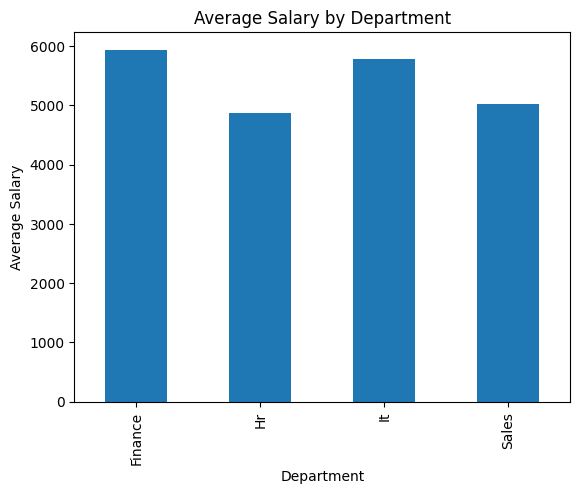

In [10]:
import matplotlib.pyplot as plt

avg_salary.plot(kind="bar")

plt.title("Average Salary by Department")

plt.xlabel("Department")

plt.ylabel("Average Salary")

plt.show()

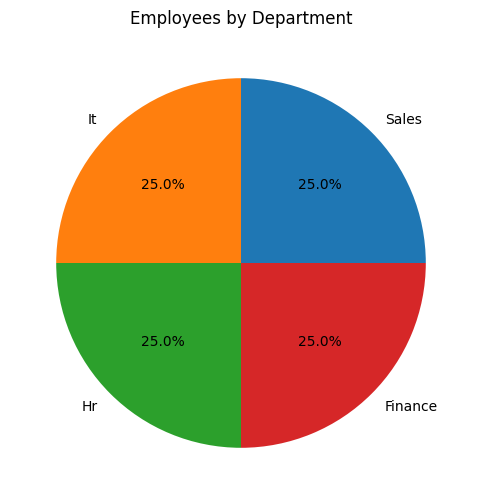

In [11]:
dept = df["Department"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    dept,
    labels=dept.index,
    autopct="%1.1f%%"
)

plt.title("Employees by Department")

plt.show()

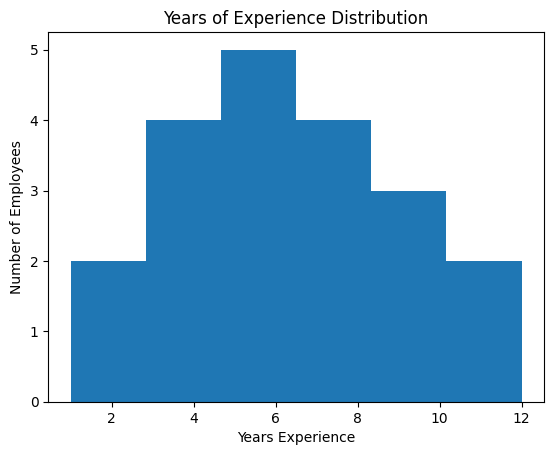

In [12]:
plt.hist(df["YearsExperience"],bins=6)

plt.title("Years of Experience Distribution")

plt.xlabel("Years Experience")

plt.ylabel("Number of Employees")

plt.show()

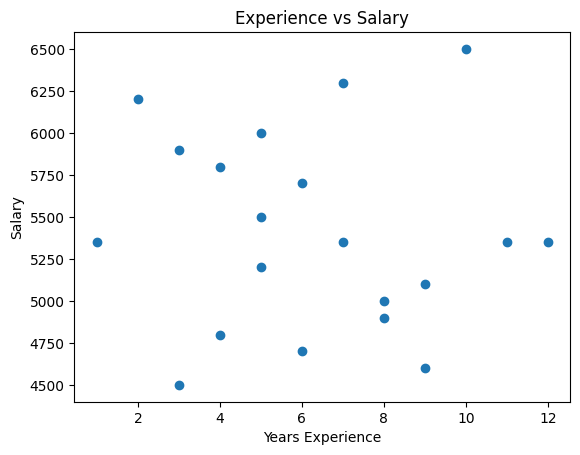

In [13]:
plt.scatter(df["YearsExperience"],df["Salary"])

plt.title("Experience vs Salary")

plt.xlabel("Years Experience")

plt.ylabel("Salary")

plt.show()

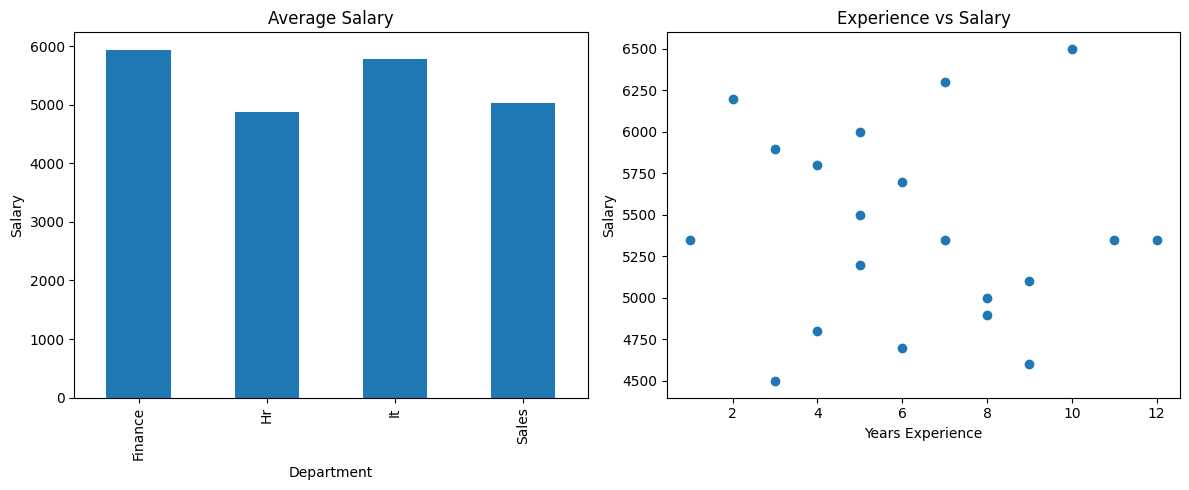

In [14]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

avg_salary.plot(kind="bar",ax=ax[0])

ax[0].set_title("Average Salary")

ax[0].set_xlabel("Department")

ax[0].set_ylabel("Salary")

ax[1].scatter(df["YearsExperience"],df["Salary"])

ax[1].set_title("Experience vs Salary")

ax[1].set_xlabel("Years Experience")

ax[1].set_ylabel("Salary")

plt.tight_layout()

plt.show()

## Part E: Summary

The employee dataset initially contained missing salary values, duplicate records, and inconsistent department names. After cleaning the data, the dataset became suitable for analysis. Salary statistics showed the average monthly salary and its variation across employees. Grouping by department revealed noticeable differences in average salary and performance ratings. The highest-paid employees were identified using salary ranking. The visualizations clearly showed the distribution of employees across departments and the spread of work experience. The scatter plot suggested a positive relationship between years of experience and salary for many employees. Overall, the project demonstrated how NumPy, Pandas, and Matplotlib can be used together for effective data analysis and visualization.